This is a companion notebook for the book [Deep Learning with Python, Third Edition](https://www.manning.com/books/deep-learning-with-python-third-edition). For readability, it only contains runnable code blocks and section titles, and omits everything else in the book: text paragraphs, figures, and pseudocode.

**If you want to be able to follow what's going on, I recommend reading the notebook side by side with your copy of the book.**

The book's contents are available online at [deeplearningwithpython.io](https://deeplearningwithpython.io).

In [1]:
!pip install keras keras-hub --upgrade -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 55.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras-nlp 0.21.1 requires keras-hub==0.21.1, but you have keras-hub 0.26.0 which is incompatible.


In [2]:
import os
os.environ["KERAS_BACKEND"] = "jax"

In [3]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

## Introduction to TensorFlow, PyTorch, JAX, and Keras

### A brief history of deep learning frameworks

### Key features

- Compute gradients
- Run tensor computations on CPU / GPU and more
- Support distributed computing

### How these frameworks relate to each other

Tensorflow - Google
PyTorch - Facebook/ Meta
JAX - Google
Keras - High level API for any of the above.  Future support MLX?

### Introduction to TensorFlow

#### First steps with TensorFlow

##### Tensors and variables in TensorFlow

###### Constant tensors

In [4]:
import tensorflow as tf
tf.ones(shape=(2, 1))

<tf.Tensor: shape=(2, 1), dtype=float32, numpy=
array([[1.],
       [1.]], dtype=float32)>

In [5]:
tf.zeros(shape=(2, 1))

<tf.Tensor: shape=(2, 1), dtype=float32, numpy=
array([[0.],
       [0.]], dtype=float32)>

In [6]:
tf.constant([1, 2, 3], dtype="float32")

<tf.Tensor: shape=(3,), dtype=float32, numpy=array([1., 2., 3.], dtype=float32)>

###### Random tensors

In [0]:
x = tf.random.normal(shape=(3, 1), mean=0., stddev=1.)
print(x)

In [0]:
x = tf.random.uniform(shape=(3, 1), minval=0., maxval=1.)
print(x)

###### Tensor assignment and the Variable class

In [7]:
import numpy as np

x = np.ones(shape=(2, 2))
x[0, 0] = 0.0

In [8]:
v = tf.Variable(initial_value=tf.random.normal(shape=(3, 1)))
print(v)

<tf.Variable 'Variable:0' shape=(3, 1) dtype=float32, numpy=
array([[0.86155796],
       [1.8286513 ],
       [0.59340113]], dtype=float32)>


In [9]:
v.assign(tf.ones((3, 1)))

<tf.Variable 'UnreadVariable' shape=(3, 1) dtype=float32, numpy=
array([[1.],
       [1.],
       [1.]], dtype=float32)>

In [0]:
v[0, 0].assign(3.)

In [0]:
v.assign_add(tf.ones((3, 1)))

##### Tensor operations: Doing math in TensorFlow

In [0]:
a = tf.ones((2, 2))
b = tf.square(a)
c = tf.sqrt(a)
d = b + c
e = tf.matmul(a, b)
f = tf.concat((a, b), axis=0)

In [0]:
def dense(inputs, W, b):
    return tf.nn.relu(tf.matmul(inputs, W) + b)

##### Gradients in TensorFlow: A second look at the GradientTape API

In [11]:
input_var = tf.Variable(initial_value=3.0)
with tf.GradientTape() as tape:
    result = tf.square(input_var)
gradient = tape.gradient(result, input_var)

print(gradient)

tf.Tensor(6.0, shape=(), dtype=float32)


In [0]:
input_const = tf.constant(3.0)
with tf.GradientTape() as tape:
    tape.watch(input_const)
    result = tf.square(input_const)
gradient = tape.gradient(result, input_const)

In [12]:
time = tf.Variable(0.0)
with tf.GradientTape() as outer_tape:
    with tf.GradientTape() as inner_tape:
        position = 4.9 * time**2
    speed = inner_tape.gradient(position, time)
acceleration = outer_tape.gradient(speed, time)

print(acceleration)

tf.Tensor(9.8, shape=(), dtype=float32)


##### Making TensorFlow functions fast using compilation

In [0]:
@tf.function
def dense(inputs, W, b):
    return tf.nn.relu(tf.matmul(inputs, W) + b)

In [0]:
@tf.function(jit_compile=True)
def dense(inputs, W, b):
    return tf.nn.relu(tf.matmul(inputs, W) + b)

#### An end-to-end example: A linear classifier in pure TensorFlow

In [13]:
import numpy as np

num_samples_per_class = 1000
negative_samples = np.random.multivariate_normal(
    mean=[0, 3], cov=[[1, 0.5], [0.5, 1]], size=num_samples_per_class
)
positive_samples = np.random.multivariate_normal(
    mean=[3, 0], cov=[[1, 0.5], [0.5, 1]], size=num_samples_per_class
)

In [14]:
inputs = np.vstack((negative_samples, positive_samples)).astype(np.float32)

In [16]:
targets = np.vstack(
    (
        np.zeros((num_samples_per_class, 1), dtype="float32"),
        np.ones((num_samples_per_class, 1), dtype="float32"),
    )
)

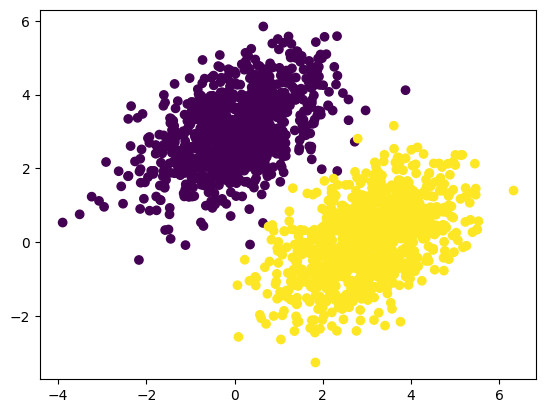

In [17]:
import matplotlib.pyplot as plt

plt.scatter(inputs[:, 0], inputs[:, 1], c=targets[:, 0])
plt.show()

In [18]:
input_dim = 2
output_dim = 1
W = tf.Variable(initial_value=tf.random.uniform(shape=(input_dim, output_dim)))
b = tf.Variable(initial_value=tf.zeros(shape=(output_dim,)))

In [19]:
def model(inputs, W, b):
    return tf.matmul(inputs, W) + b

In [20]:
def mean_squared_error(targets, predictions):
    per_sample_losses = tf.square(targets - predictions)
    return tf.reduce_mean(per_sample_losses)

In [21]:
learning_rate = 0.1

@tf.function(jit_compile=True)
def training_step(inputs, targets, W, b):
    with tf.GradientTape() as tape:
        predictions = model(inputs, W, b)
        loss = mean_squared_error(predictions, targets)
    grad_loss_wrt_W, grad_loss_wrt_b = tape.gradient(loss, [W, b])
    W.assign_sub(grad_loss_wrt_W * learning_rate)
    b.assign_sub(grad_loss_wrt_b * learning_rate)
    return loss

In [22]:
for step in range(40):
    loss = training_step(inputs, targets, W, b)
    print(f"Loss at step {step}: {loss:.4f}")

Loss at step 0: 5.7367
Loss at step 1: 0.9543
Loss at step 2: 0.2711
Loss at step 3: 0.1654
Loss at step 4: 0.1418
Loss at step 5: 0.1305
Loss at step 6: 0.1215
Loss at step 7: 0.1135
Loss at step 8: 0.1062
Loss at step 9: 0.0995
Loss at step 10: 0.0934
Loss at step 11: 0.0877
Loss at step 12: 0.0826
Loss at step 13: 0.0778
Loss at step 14: 0.0735
Loss at step 15: 0.0695
Loss at step 16: 0.0659
Loss at step 17: 0.0625
Loss at step 18: 0.0594
Loss at step 19: 0.0566
Loss at step 20: 0.0540
Loss at step 21: 0.0517
Loss at step 22: 0.0495
Loss at step 23: 0.0475
Loss at step 24: 0.0457
Loss at step 25: 0.0440
Loss at step 26: 0.0425
Loss at step 27: 0.0411
Loss at step 28: 0.0398
Loss at step 29: 0.0386
Loss at step 30: 0.0375
Loss at step 31: 0.0365
Loss at step 32: 0.0356
Loss at step 33: 0.0347
Loss at step 34: 0.0340
Loss at step 35: 0.0333
Loss at step 36: 0.0326
Loss at step 37: 0.0320
Loss at step 38: 0.0315
Loss at step 39: 0.0310


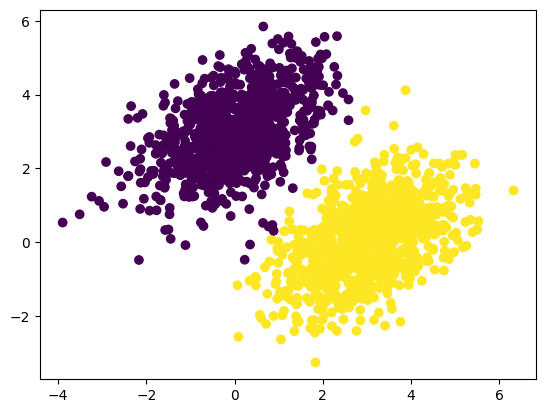

In [23]:
predictions = model(inputs, W, b)
plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:, 0] > 0.5)
plt.show()

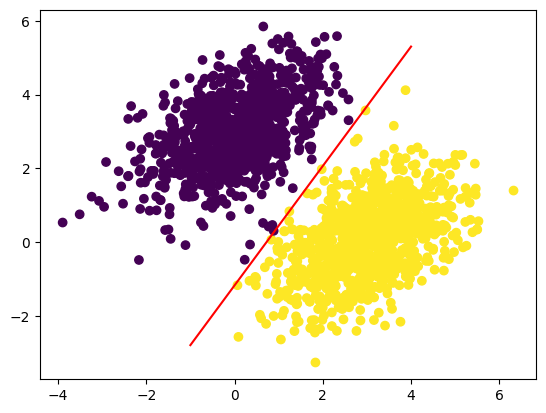

In [24]:
x = np.linspace(-1, 4, 100)
y = -W[0] / W[1] * x + (0.5 - b) / W[1]
plt.plot(x, y, "-r")
plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:, 0] > 0.5)

#### What makes the TensorFlow approach unique

Pros:
- Fast execution due to graph mode and XLA compilation
- Extremeely feature complete and mature
- Strong support for production deployment

Cons:
- Sprawling API 
- Numerical API inconsistent with Numpy 
- HuggingFace support for TensorFlow is limited

### Introduction to PyTorch

#### First steps with PyTorch

##### Tensors and parameters in PyTorch

###### Constant tensors

In [25]:
import torch
torch.ones(size=(2, 1))

tensor([[1.],
        [1.]])

In [26]:
torch.zeros(size=(2, 1))

tensor([[0.],
        [0.]])

In [27]:
torch.tensor([1, 2, 3], dtype=torch.float32)

tensor([1., 2., 3.])

###### Random tensors

In [28]:
torch.normal(
mean=torch.zeros(size=(3, 1)),
std=torch.ones(size=(3, 1)))

tensor([[-0.8994],
        [-0.7718],
        [ 1.5008]])

In [0]:
torch.rand(3, 1)

###### Tensor assignment and the Parameter class

In [29]:
x = torch.zeros(size=(2, 1))
x[0, 0] = 1.
x

tensor([[1.],
        [0.]])

In [30]:
x = torch.zeros(size=(2, 1))
p = torch.nn.parameter.Parameter(data=x)

Parameter provides semantic clarity and is used to indicate that a tensor should be considered a trainable parameter of a model.  It is a subclass of Tensor, so it can be used in all the same ways as a regular tensor.

##### Tensor operations: Doing math in PyTorch

In [0]:
a = torch.ones((2, 2))
b = torch.square(a)
c = torch.sqrt(a)
d = b + c
e = torch.matmul(a, b)
f = torch.cat((a, b), dim=0)

In [0]:
def dense(inputs, W, b):
    return torch.nn.relu(torch.matmul(inputs, W) + b)

##### Computing gradients with PyTorch

In [31]:
input_var = torch.tensor(3.0, requires_grad=True)
result = torch.square(input_var)
result.backward()
gradient = input_var.grad
gradient

tensor(6.)

In [32]:
result = torch.square(input_var)
result.backward()
input_var.grad
gradient

tensor(12.)

Gradients accumulated in pytorch, which is useful for some applications but can lead to bugs if you forget to zero them out.

In [0]:
input_var.grad = None

#### An end-to-end example: A linear classifier in pure PyTorch

In [33]:
input_dim = 2
output_dim = 1

W = torch.rand(input_dim, output_dim, requires_grad=True)
b = torch.zeros(output_dim, requires_grad=True)

In [34]:
def model(inputs, W, b):
    return torch.matmul(inputs, W) + b

In [35]:
def mean_squared_error(targets, predictions):
    per_sample_losses = torch.square(targets - predictions)
    return torch.mean(per_sample_losses)

In [36]:
learning_rate = 0.1

def training_step(inputs, targets, W, b):
    predictions = model(inputs)
    loss = mean_squared_error(targets, predictions)
    loss.backward()
    grad_loss_wrt_W, grad_loss_wrt_b = W.grad, b.grad
    with torch.no_grad():
        W -= grad_loss_wrt_W * learning_rate
        b -= grad_loss_wrt_b * learning_rate
    W.grad = None
    b.grad = None
    return loss

##### Packaging state and computation with the Module class

In [37]:
class LinearModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.W = torch.nn.Parameter(torch.rand(input_dim, output_dim))
        self.b = torch.nn.Parameter(torch.zeros(output_dim))

    def forward(self, inputs):
        return torch.matmul(inputs, self.W) + self.b

In [38]:
model = LinearModel()

In [39]:
torch_inputs = torch.tensor(inputs)
output = model(torch_inputs)

In [40]:
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [ ]:
def training_step(inputs, targets):
    predictions = model(inputs)
    loss = mean_squared_error(targets, predictions)
    loss.backward()
    optimizer.step()
    model.zero_grad() # zero out gradients after each step to prevent accumulation
    return loss

##### Making PyTorch modules fast using compilation

In [42]:
compiled_model = torch.compile(model)

In [0]:
@torch.compile
def dense(inputs, W, b):
    return torch.nn.relu(torch.matmul(inputs, W) + b)

#### What makes the PyTorch approach unique

Pros:
- Code executes eagerly by default, making it easier to debug and experiment with.
- HuggingFace support for PyTorch is excellent, with most models only available in PyTorch.
 
Cons:
- Numerical API inconsistent with Numpy
- Slowest of all the major frameworks, sometimes even with compilation. 
- Compilation (Dynamo) is 'quite ineffective and full of trap doors'.  Only used by small minority of users. 

### Introduction to JAX

#### First steps with JAX

#### Tensors in JAX

Jax 'numpy' API is designed to be as close as possible to the original Numpy API, which makes it very easy to learn and use for anyone familiar with Numpy.

In [43]:
from jax import numpy as jnp
jnp.ones(shape=(2, 1))

Array([[1.],
       [1.]], dtype=float32)

In [44]:
jnp.zeros(shape=(2, 1))

Array([[0.],
       [0.]], dtype=float32)

In [45]:
jnp.array([1, 2, 3], dtype="float32")

Array([1., 2., 3.], dtype=float32)

#### Random number generation in JAX

In [0]:
np.random.normal(size=(3,))

In [0]:
np.random.normal(size=(3,))

In [0]:
def apply_noise(x, seed):
    np.random.seed(seed)
    x = x * np.random.normal((3,))
    return x

seed = 1337
y = apply_noise(x, seed)
seed += 1
z = apply_noise(x, seed)

Jax is purely functional, so it doesn't have a global random state.  Instead, you have to explicitly pass around a random key.

In [46]:
import jax

seed_key = jax.random.key(1337)

In [47]:
seed_key = jax.random.key(0)
jax.random.normal(seed_key, shape=(3,))

Array([ 1.6226422 ,  2.0252647 , -0.43359444], dtype=float32)

In [48]:
seed_key = jax.random.key(123)
jax.random.normal(seed_key, shape=(3,))

Array([1.6359469 , 0.8408094 , 0.02212393], dtype=float32)

In [49]:
jax.random.normal(seed_key, shape=(3,))

Array([1.6359469 , 0.8408094 , 0.02212393], dtype=float32)

In [50]:
seed_key = jax.random.key(123)
jax.random.normal(seed_key, shape=(3,))

Array([1.6359469 , 0.8408094 , 0.02212393], dtype=float32)

In [51]:
new_seed_key = jax.random.split(seed_key, num=1)[0]
jax.random.normal(new_seed_key, shape=(3,))

Array([-0.49093357, -0.9478693 , -1.775197  ], dtype=float32)

##### Tensor assignment

Tensors (like in Tensorflow) are immutable in JAX, so you can't assign to them.  Instead, you have to create new tensors with the updated values.

In [52]:
x = jnp.array([1, 2, 3], dtype="float32")
new_x = x.at[0].set(10)

##### Tensor operations: Doing math in JAX

In [53]:
a = jnp.ones((2, 2))
b = jnp.square(a)
c = jnp.sqrt(a)
d = b + c
e = jnp.matmul(a, b)
e *= d

In [54]:
def dense(inputs, W, b):
    return jax.nn.relu(jnp.matmul(inputs, W) + b)

##### Computing gradients with JAX

Gradients in Jax are higher-order functions, what the author calls 'metaprogramming'.  This just means the grad function takes a function and returns the derivative as a function (not a value)

In [55]:
def compute_loss(input_var):
    return jnp.square(input_var)

In [56]:
grad_fn = jax.grad(compute_loss)

In [59]:
input_var = jnp.array(3.0) # must be a JAX array, not a Python scalar, for grad to work
grad_of_loss_wrt_input_var = grad_fn(input_var)
grad_of_loss_wrt_input_var

Array(6., dtype=float32, weak_type=True)

##### JAX gradient-computation best practices

###### Returning the loss value

In [60]:
grad_fn = jax.value_and_grad(compute_loss)
output, grad_of_loss_wrt_input_var = grad_fn(input_var)

###### Getting gradients for a complex function

###### Returning auxiliary outputs

##### Making JAX functions fast with @jax.jit

In [61]:
@jax.jit
def dense(inputs, W, b):
    return jax.nn.relu(jnp.matmul(inputs, W) + b)

#### An end-to-end example: A linear classifier in pure JAX

In [62]:
def model(inputs, W, b):
    return jnp.matmul(inputs, W) + b

def mean_squared_error(targets, predictions):
    per_sample_losses = jnp.square(targets - predictions)
    return jnp.mean(per_sample_losses)

In [63]:
def compute_loss(state, inputs, targets):
    W, b = state
    predictions = model(inputs, W, b)
    loss = mean_squared_error(targets, predictions)
    return loss

In [64]:
grad_fn = jax.value_and_grad(compute_loss)

In [65]:
learning_rate = 0.1

@jax.jit
def training_step(inputs, targets, W, b):
    loss, grads = grad_fn((W, b), inputs, targets)
    grad_wrt_W, grad_wrt_b = grads
    W = W - grad_wrt_W * learning_rate
    b = b - grad_wrt_b * learning_rate
    return loss, W, b

In [66]:
input_dim = 2
output_dim = 1

W = jax.numpy.array(np.random.uniform(size=(input_dim, output_dim)))
b = jax.numpy.array(np.zeros(shape=(output_dim,)))
state = (W, b)
for step in range(40):
    loss, W, b = training_step(inputs, targets, W, b)
    print(f"Loss at step {step}: {loss:.4f}")

Loss at step 0: 5.7116
Loss at step 1: 0.6328
Loss at step 2: 0.2092
Loss at step 3: 0.1415
Loss at step 4: 0.1245
Loss at step 5: 0.1152
Loss at step 6: 0.1077
Loss at step 7: 0.1008
Loss at step 8: 0.0946
Loss at step 9: 0.0888
Loss at step 10: 0.0836
Loss at step 11: 0.0788
Loss at step 12: 0.0743
Loss at step 13: 0.0703
Loss at step 14: 0.0666
Loss at step 15: 0.0632
Loss at step 16: 0.0600
Loss at step 17: 0.0572
Loss at step 18: 0.0545
Loss at step 19: 0.0521
Loss at step 20: 0.0499
Loss at step 21: 0.0479
Loss at step 22: 0.0460
Loss at step 23: 0.0443
Loss at step 24: 0.0428
Loss at step 25: 0.0413
Loss at step 26: 0.0400
Loss at step 27: 0.0388
Loss at step 28: 0.0377
Loss at step 29: 0.0367
Loss at step 30: 0.0358
Loss at step 31: 0.0349
Loss at step 32: 0.0341
Loss at step 33: 0.0334
Loss at step 34: 0.0327
Loss at step 35: 0.0321
Loss at step 36: 0.0316
Loss at step 37: 0.0311
Loss at step 38: 0.0306
Loss at step 39: 0.0302


#### What makes the JAX approach unique

Pros:
- Fast! 
- Numerical API consistent with Numpy
- Best fit for TPUs as it was developed by Google for their TPUs

Cons:
- Harder to debug due to use of 'metaprogramming' and compilation
- Low level training loops tend to me more verbose.

### Introduction to Keras

#### First steps with Keras

##### Picking a backend framework

In [0]:
import os

os.environ["KERAS_BACKEND"] = "jax"

import keras

#### Layers: The building blocks of deep learning

##### The base `Layer` class in Keras

In [67]:
import keras

class SimpleDense(keras.Layer):
    def __init__(self, units, activation=None):
        super().__init__()
        self.units = units
        self.activation = activation

    def build(self, input_shape):
        batch_dim, input_dim = input_shape
        self.W = self.add_weight(
            shape=(input_dim, self.units), initializer="random_normal"
        )
        self.b = self.add_weight(shape=(self.units,), initializer="zeros")

    def call(self, inputs):
        y = keras.ops.matmul(inputs, self.W) + self.b
        if self.activation is not None:
            y = self.activation(y)
        return y

In [68]:
my_dense = SimpleDense(units=32, activation=keras.ops.relu)
input_tensor = keras.ops.ones(shape=(2, 784))
output_tensor = my_dense(input_tensor)
print(output_tensor.shape)

(2, 32)


##### Automatic shape inference: Building layers on the fly

In [69]:
from keras import layers

layer = layers.Dense(32, activation="relu")

In [70]:
from keras import models
from keras import layers

model = models.Sequential(
    [
        layers.Dense(32, activation="relu"),
        layers.Dense(32),
    ]
)

In [71]:
model = keras.Sequential(
    [
        SimpleDense(32, activation="relu"),
        SimpleDense(64, activation="relu"),
        SimpleDense(32, activation="relu"),
        SimpleDense(10, activation="softmax"),
    ]
)

#### From layers to models

#### The "compile" step: Configuring the learning process

In [72]:
model = keras.Sequential([keras.layers.Dense(1)])
model.compile(
    optimizer="rmsprop",
    loss="mean_squared_error",
    metrics=["accuracy"],
)

In [73]:
model.compile(
    optimizer=keras.optimizers.RMSprop(),
    loss=keras.losses.MeanSquaredError(),
    metrics=[keras.metrics.BinaryAccuracy()],
)

#### Picking a loss function

#### Understanding the fit method

In [74]:
history = model.fit(
    inputs,
    targets,
    epochs=5,
    batch_size=128,
)

Epoch 1/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - binary_accuracy: 0.2445 - loss: 14.2250
Epoch 2/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.2435 - loss: 13.8154
Epoch 3/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.2455 - loss: 13.4629
Epoch 4/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.2450 - loss: 13.1220
Epoch 5/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.2455 - loss: 12.7856


In [75]:
history.history

{'binary_accuracy': [0.24449999630451202,
  0.2434999942779541,
  0.24549999833106995,
  0.24500000476837158,
  0.24549999833106995],
 'loss': [14.22495174407959,
  13.815382957458496,
  13.462865829467773,
  13.121977806091309,
  12.785605430603027]}

#### Monitoring loss and metrics on validation data

In [76]:
model = keras.Sequential([keras.layers.Dense(1)])
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=0.1),
    loss=keras.losses.MeanSquaredError(),
    metrics=[keras.metrics.BinaryAccuracy()],
)

indices_permutation = np.random.permutation(len(inputs))
shuffled_inputs = inputs[indices_permutation]
shuffled_targets = targets[indices_permutation]

num_validation_samples = int(0.3 * len(inputs))
val_inputs = shuffled_inputs[:num_validation_samples]
val_targets = shuffled_targets[:num_validation_samples]
training_inputs = shuffled_inputs[num_validation_samples:]
training_targets = shuffled_targets[num_validation_samples:]
model.fit(
    training_inputs,
    training_targets,
    epochs=5,
    batch_size=16,
    validation_data=(val_inputs, val_targets),
)

Epoch 1/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - binary_accuracy: 0.8600 - loss: 0.5658 - val_binary_accuracy: 0.9967 - val_loss: 0.0275
Epoch 2/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.9686 - loss: 0.0675 - val_binary_accuracy: 0.9967 - val_loss: 0.0283
Epoch 3/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.9536 - loss: 0.0730 - val_binary_accuracy: 0.6983 - val_loss: 0.1690
Epoch 4/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.9579 - loss: 0.0732 - val_binary_accuracy: 0.9950 - val_loss: 0.0356
Epoch 5/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.9443 - loss: 0.0799 - val_binary_accuracy: 0.9983 - val_loss: 0.0301


#### Inference: Using a model after training

In [77]:
predictions = model.predict(val_inputs, batch_size=128)
print(predictions[:10])

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
[[ 0.9135479 ]
 [ 0.11440986]
 [-0.07628265]
 [ 0.15790737]
 [ 0.09390023]
 [ 0.47648576]
 [ 0.0544104 ]
 [ 0.1536997 ]
 [ 0.88441694]
 [-0.05638525]]
